In [1]:
# Bootstrap the import path so `src/` can be imported from notebooks.
from pathlib import Path
import sys

# If you're running the notebook from lumbar-coordinate/notebooks/, go one level up.
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent.resolve()
else:
    # If you open the notebook from the repo root, use that directly.
    PROJECT_ROOT = Path.cwd().resolve()

# Add the project root (which contains `src/`) to sys.path once per session.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\hyeon\Documents\miniconda_medimg_env\lumbar-coordinate


In [2]:
# --- 02_train.ipynb ---
from pathlib import Path
import pandas as pd
from torch.utils.data import DataLoader

from src.config import Paths, TrainConfig, make_run_dirs
from src.utils import set_seed, save_config_snapshot
from src.transforms import build_transforms
from src.dataset import LumbarDataset
from src.model import get_model
from src.engine import fit

# Paths & config
PROJECT_ROOT = Path.cwd().resolve().parents[0] if (Path.cwd().name == 'notebooks') else Path.cwd()
paths = Paths.build(project_root=PROJECT_ROOT)
# cfg = TrainConfig(epochs=20, image_size=320, batch_size=32, backbone='resnet18', pretrained=True)
from src.config import TrainConfig
cfg = TrainConfig(
    epochs=40,
    scheduler='plateau',          # or 'cosine.'
    plateau_factor=0.5,
    plateau_patience=3,
    min_lr=1e-6,
    early_stop_patience=7,
    early_stop_min_delta=1e-4,
    order_reg_lambda=0.1,         # try 0.05–0.2
    order_reg_margin=0.0          # try 0.005 if you want a small gap
)

# Reproducibility
set_seed(cfg.seed)

# Prepare run directory
run_dir = make_run_dirs(paths)
save_config_snapshot(run_dir, cfg)

# Load splits (created by 01_split.ipynb)
processed_dir = PROJECT_ROOT / "data" / "processed"
df_train = pd.read_csv(processed_dir / "train.csv")
df_val   = pd.read_csv(processed_dir / "val.csv")

# Transforms & datasets
train_tfms, val_tfms = build_transforms(cfg.image_size)
train_ds = LumbarDataset(df_train, images_root=paths.data_images_dir, levels=list(cfg.levels), transform=train_tfms, allow_missing=True)
val_ds   = LumbarDataset(df_val,   images_root=paths.data_images_dir, levels=list(cfg.levels), transform=val_tfms,   allow_missing=True)

train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

# Model
model = get_model(backbone=cfg.backbone, pretrained=cfg.pretrained, out_dim=cfg.out_dim)

# Train
best_ckpt = fit(model, train_dl, val_dl, cfg, run_dir)
print("Best checkpoint:", best_ckpt)
print("Metrics logged to:", run_dir / "metrics.csv")

C:\Users\hyeon\miniconda3\envs\medimg\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01 | train 0.1463 | val_total 0.0951 | val_base 0.0958 | ord 0.0009 | lr 1.00e-03 | per-level MAE [0.0556 0.1287 0.1091 0.134  0.0681]
Epoch 02 | train 0.0395 | val_total 0.0490 | val_base 0.0502 | ord 0.0002 | lr 1.00e-03 | per-level MAE [0.0632 0.0423 0.041  0.0722 0.0489]
Epoch 03 | train 0.0351 | val_total 0.0481 | val_base 0.0474 | ord 0.0000 | lr 1.00e-03 | per-level MAE [0.0662 0.062  0.0401 0.0511 0.045 ]
Epoch 04 | train 0.0398 | val_total 0.0428 | val_base 0.0424 | ord 0.0000 | lr 1.00e-03 | per-level MAE [0.0378 0.0446 0.0609 0.041  0.0535]
Epoch 05 | train 0.0299 | val_total 0.0291 | val_base 0.0295 | ord 0.0000 | lr 1.00e-03 | per-level MAE [0.0339 0.0304 0.0336 0.0294 0.0411]
Epoch 06 | train 0.0301 | val_total 0.0318 | val_base 0.0297 | ord 0.0005 | lr 1.00e-03 | per-level MAE [0.0318 0.0284 0.0436 0.042  0.0347]
Epoch 07 | train 0.0315 | val_total 0.0319 | val_base 0.0305 | ord 0.0002 | lr 1.00e-03 | per-level MAE [0.0365 0.041  0.0299 0.0348 0.0405]
Epoch 08 | tr

,epoch,train_total_loss,val_total_loss,val_base_loss,val_order_penalty,lr,mae_0,mae_1,mae_2,mae_3,mae_4
35,36,0.007152,0.007660,0.008191,0.0,0.000063,0.013587,0.013052,0.011599,0.009408,0.009513
36,37,0.005880,0.008458,0.008444,0.0,0.000063,0.013273,0.012925,0.012104,0.011117,0.012597
37,38,0.006076,0.007022,0.007580,0.0,0.000063,0.015079,0.011636,0.009540,0.008984,0.008603
38,39,0.005946,0.011220,0.009741,0.0,0.000063,0.016593,0.015559,0.015708,0.015874,0.013133
39,40,0.007330,0.007355,0.007852,0.0,0.000063,0.013121,0.011794,0.010366,0.008991,0.011669


KeyError: 'train_loss'

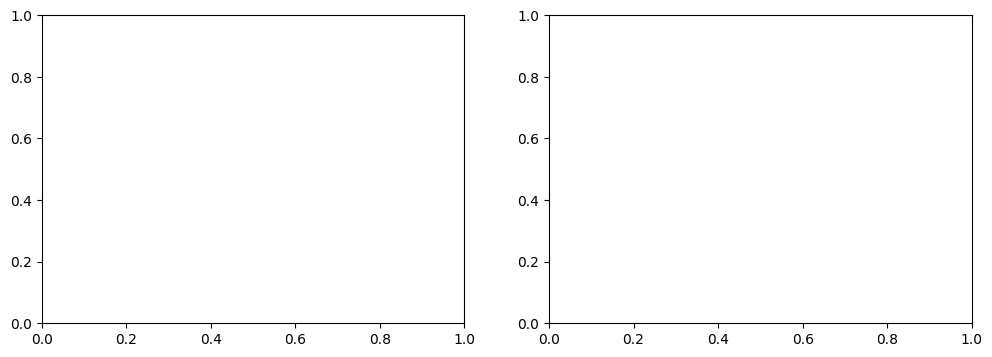

In [1]:
# training outcome and curves

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Pick a run to visualize
RUNS_DIR = (Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()) / "runs"
RUN_DIR = max(RUNS_DIR.glob("run_*"))  # or set explicitly

dfm = pd.read_csv(RUN_DIR / "metrics.csv")
display(dfm.tail())

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(dfm["epoch"], dfm["train_loss"], label="train")
ax[0].plot(dfm["epoch"], dfm["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True)

# Per-level MAE columns are mae_0..mae_4 (L1/2..L5/S1)
for i, lvl in enumerate(["L1/L2","L2/L3","L3/L4","L4/L5","L5/S1"]):
    ax[1].plot(dfm["epoch"], dfm[f"mae_{i}"], label=lvl)
ax[1].set_title("Validation MAE (normalized)"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)
plt.show()